In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Parameters
# -----------------------------
params = {
    # Calcium flux parameters
    "k_PMCA": 0.4,      # Wang extrusion rate 
    "V_Pmax": 4.5,      # Wang PMCA pump max rate 
    "V_s": 4.5,         # Wang/Lytton SR uptake rate max for SERCA pump between 0.1 and 0.5
    "k_s": 0.1,         # Wang/Lytton SR uptake affinity for SERCA pump between 0.1 and 0.5 
    "k_leak": 0.1,      # Wang SR leak
    "F": 96485.3329,    # Physical Faraday's constant 

    "P": 0.35, # IP3 production proxy by agonist 

    "gamma": 5.5,
    "delta": 0.05,

    "g_Ca": 9.0,        # Wang nS mM^-1 
    "V_m": -50.0,       # Wang mV 
    "k_m": 12.0,        # Wang mV 
    "R": 8314,         # Physical mJ/(mol K)
    "T": 310.0,          # Wang K (37°C) 

    "a_0": 0.05, # Wang
    "a_1": 0.25, # Wang
    "a_2": 1, # Wang

    "k_1": 2000, # Wang,. DeY 
    "k_-1": 260, # Wang, DeY
    "K_1": 0.13, # Wang, DeY - derived 
    "k_2": 1, # Wang, DeY
    "k_-2": 1.05, # Wang, DeY
    "K_2": 1.05, # Wang, DeY - derived
    "k_3": 2000, # Wang, DeY
    "k_-3": 1886, # Wang, DeY
    "K_3": 0.943, # Wang, DeY - derived
    "k_4": 1, # Wang, DeY
    "k_-4": 0.145, # Wang, DeY
    "K_4": 0.145, # Wang, DeY - derived
    "k_5": 100, # Wang, DeY
    "k_-5": 8.2, # Wang, DeY
    "K_5": 0.082, # Wang, DeY - derived

    # Channel gains
    "k_IP3R": 5.55, #Wang
    "k_RyR": 5.0, #Wang 
    "k_ryr0": 0.0072, # Wang and Friel RyR opening rate
    "k_ryr1": 0.334, # Wang and Friel and Shannon RyR closing rate
    "k_ryr2": 0.5, # Wang and Friel and Shannon RyR activation affinity
    "k_ryr3": 38.0, # Wang and Shannon RyR inactivation affinity

    # Voltage parameters
    "c_m": 1.0, # Lata
    "I_stim": 0.1175, # Lata

    # Contraction
    "alpha": 3.0, #Lata - uterine
    "beta": 0.001, #Lata - uterine
    "n_F": 4, # Lata - uterine

    # Functional parameters
    "n": 4, # Wang - Hill coefficient for SERCA channel activation 1, 2 or 4
    "ns": 2, # Wang and Lytton
    "n2": 3, # Wang 3 or 5 

    "E": 5, 
    "k_e1": 0.01,
    "k_e2": 0.2, 
    "k_e_in": 0.9, 
    "h": 4, 
    "EC50": 2000
}

In [3]:
# -----------------------------
# Flux definitions
# -----------------------------

def e_eff(p):
    return (1-p["k_e_in"]*p["E"])

def J_in1(V, Ca_in, Ca_0, p):
    return p["a_0"]-(p["a_1"]*I_Ca(V, Ca_in, Ca_0, p)/(2*p["F"])) * e_eff(p) +p["a_2"]*p["P"] 

def m_inf(V, p):
    return 1.0 / (1.0 + np.exp(-(V - p["V_m"]) / p["k_m"]))

def V_Ca(V, Ca_in, Ca_0, p):
    F = p["F"]
    R = p["R"]
    T = p["T"]

    exp_term = np.exp(-2.0 * V * F / (R * T))

    denom = 1.0 - exp_term
    if np.abs(denom) < 1e-8:
        return 1e-8

    return V * (Ca_in - Ca_0 * exp_term) / denom

def I_Ca(V, Ca_in, Ca_0, p):
    m = m_inf(V, p)
    Vca = V_Ca(V, Ca_in, Ca_0, p)
    return p["g_Ca"] * (m**2) * Vca

def J_PMCA_Hill(Ca_in, p):
    return p["V_Pmax"] * (Ca_in**p["n"]) / (p["k_PMCA"]**p["n"] + Ca_in**p["n"]) # - Ca_0**p["n"]

def J_SERCA_Hill(Ca_in, p):
    return p["V_s"] * (Ca_in**p["ns"]) / (p["k_s"]**p["ns"] + Ca_in**p["ns"]) # - Ca_0**p["n"]

def J_leak(Ca_SR, Ca_in, p):
    return p["k_leak"] * (Ca_SR - Ca_in)

def J_IP3R_Wang(Ca_SR, Ca_in, y_g, p):
    return p["k_IP3R"] * P_IP3R(Ca_in, y_g, p) * (Ca_SR - Ca_in)

def P_IP3R(Ca_in, y, p):
    num = p["P"] * Ca_in * (1 - y)
    den = (p["P"] + p["K_1"]) * (Ca_in + p["K_5"])
    return (num / den) ** 3

def dy_dt(y, p, Ca_in):
    f1 = (p["k_-4"] * p["K_2"] * p["K_1"] + p["k_-2"] * p["K_4"] * p["P"]) * Ca_in / (p["K_4"] * p["K_2"] * (p["K_1"] + p["P"]))
    f2 = (p["k_-2"] * p["P"] + p["k_-4"] * p["K_3"]) / (p["K_3"] + p["P"])
    return f1 * (1.0 - y) - f2 * y

def J_RyR_Wang(Ca_SR, Ca_in, p):
    return p["k_RyR"] * P_RyR(Ca_in, Ca_SR, p) * (Ca_SR - Ca_in)

def P_RyR(Ca_in, Ca_SR, p):
    # CICR activation term (cytosolic Ca)
    activation = (
        p["k_ryr0"]
        + (p["k_ryr1"] * Ca_in**3) / (p["k_ryr2"]**3 + Ca_in**3)
    )

    # SR load dependence
    sr_term = Ca_SR**4 / (p["k_ryr3"]**4 + Ca_SR**4)

    return activation * sr_term

In [4]:
# -----------------------------
# ODE system
# -----------------------------

def model(t, state, p):
    Ca_0, Ca_in, Ca_SR, V, y_g = state

    # Fluxes
    Jin = J_in1(V, Ca_in, Ca_0, p)
    JPMCA = J_PMCA_Hill(Ca_in, p)
    JSERCA = J_SERCA_Hill(Ca_in, p)

    dyg_dt = dy_dt(y_g, p, Ca_in)

    Jip3r = J_IP3R_Wang(Ca_SR, Ca_in, y_g, p)
    Jryr = J_RyR_Wang(Ca_SR, Ca_in, p)
    Jleak = J_leak(Ca_SR, Ca_in, p)

    # Calcium dynamics
    dCa0_dt = JPMCA - Jin
    dCain_dt = p["delta"]*(Jin - JPMCA) - JSERCA + Jip3r + Jryr + Jleak
    dCaSR_dt = p["gamma"]*(JSERCA - Jip3r - Jryr - Jleak)

    # Membrane voltage (simple RC model)
    dV_dt = 0
    # 1/p["c_m"]*(Ca_0 - Ca_in) 

    return [dCa0_dt, dCain_dt, dCaSR_dt, dV_dt, dyg_dt]

In [5]:
# -----------------------------
# Contraction function
# -----------------------------
def contraction(Ca_in, p):
    return (p["alpha"] * Ca_in**p["n_F"] / ((p["beta"]*(1+p["k_e2"]*p["E"]))**p["n_F"] + Ca_in**p["n_F"])) * (1-p["k_e1"]*p["E"])

In [6]:
# -----------------------------
# Simulation
# -----------------------------
y0 = [1000, 0.112, 24, -60, 0]  # initial conditions for Ca_0, Ca_in, Ca_SR, V, y_g Wang 

t_span = (0, 1000)
t_eval = np.linspace(*t_span, 1000000)

sol = solve_ivp(model, t_span, y0, args=(params,), t_eval=t_eval, method='BDF')

# Extract variables
Ca_0 = sol.y[0]
Ca_in = sol.y[1]
Ca_SR = sol.y[2]
V = sol.y[3]
y_g = sol.y[4]

F = contraction(Ca_in, params)

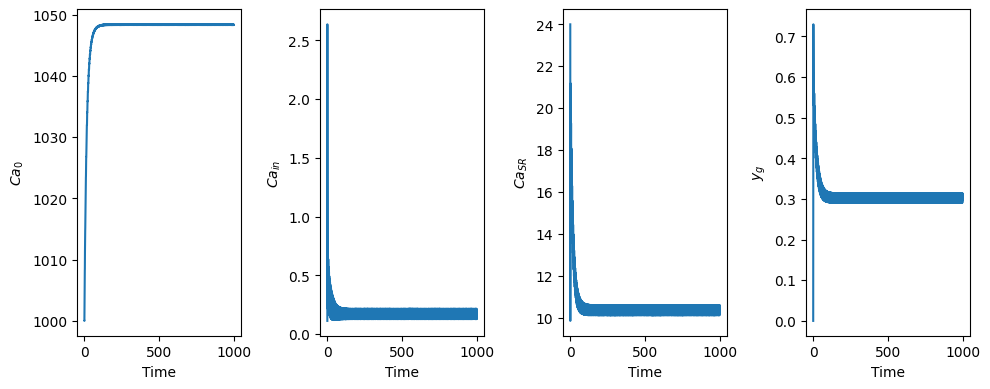

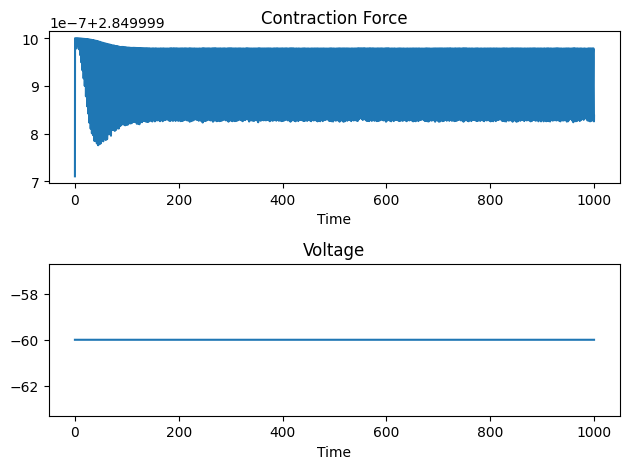

In [7]:
# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1,4,1)
plt.plot(sol.t, Ca_0, label="Ca_0")
plt.ylabel(r"$Ca_{0}$")
plt.xlabel("Time")
plt.subplot(1,4,2)
plt.plot(sol.t, Ca_in, label="Ca_in")
plt.ylabel(r"$Ca_{in}$")
plt.xlabel("Time")
plt.subplot(1,4,3)
plt.plot(sol.t, Ca_SR, label="Ca_SR")
plt.ylabel(r"$Ca_{SR}$")
plt.xlabel("Time")
plt.subplot(1,4,4)
plt.plot(sol.t, y_g, label="y_g")
plt.ylabel(r"$y_g$")
plt.xlabel("Time")
# plt.ylim(0,2)
# plt.legend()

plt.tight_layout()
plt.show()

plt.figure()
plt.subplot(2,1,1)
plt.plot(sol.t, F, label="Force (F)")
plt.title("Contraction Force")
plt.xlabel("Time")
# plt.legend()
plt.subplot(2,1,2)
plt.plot(sol.t, V, label="Voltage (V)")
plt.title("Voltage")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [8]:
from scipy.optimize import root, least_squares

def get_default_params():
    return params

def residuals(x, p):
    Ca_0, Ca_in, Ca_SR, V, y_g = x

    V = 0

    # Fluxes
    Jin = J_in1(V, Ca_in, Ca_0, p)
    JPMCA = J_PMCA_Hill(Ca_in, p)
    JSERCA = J_SERCA_Hill(Ca_in, p)

    dyg_dt = dy_dt(y_g, p, Ca_in)

    Jip3r = J_IP3R_Wang(Ca_SR, Ca_in, y_g, p)
    Jryr = J_RyR_Wang(Ca_SR, Ca_in, p)
    Jleak = J_leak(Ca_SR, Ca_in, p)

    # Calcium dynamics
    dCa0_dt = JPMCA - Jin
    dCain_dt = p["delta"]*(Jin - JPMCA) - JSERCA + Jip3r + Jryr + Jleak
    dCaSR_dt = p["gamma"]*(JSERCA - Jip3r - Jryr - Jleak)

    # Membrane voltage (simple RC model)
    dV_dt = -60
    # 1/p["c_m"]*(Ca_0 - Ca_in) 

    return [dCa0_dt, dCain_dt, dCaSR_dt, dV_dt, dyg_dt]

def solve_with_root(x0, p):
    # sol = root(lambda x: residuals(x, p), x0, method="hybr")    

    # sol = least_squares(
    #     lambda x: residuals(x, p),
    #     x0,
    #     bounds=(0, np.inf),
    #     method="trf",
    #     # x_scale="jac",
    #     ftol=1e-12,
    #     xtol=1e-12,
    #     gtol=1e-12
    #     )

    lower_bounds = [1e-6, 1e-6, 1e-6, -120.0, 0.0]

    # --- Primary attempt: least_squares with bounds ---
    sol = least_squares(
        lambda x: residuals(x, p),
        x0,
        bounds=(lower_bounds, np.inf),
        method='trf',
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=10000
    )

    return {
        "x": sol.x,
        "success": sol.success,
        "message": sol.message,
        "fun": sol.fun,
        "nfev": sol.nfev,
        "status": sol.status,
    }

if __name__ == "__main__":
    p = get_default_params()

    x0 = np.mean(sol.y[:,-100:], axis=1)
    # np.array([1050, 0.1, 25.0, 0])
    out = solve_with_root(x0, p)

    print("Single solve")
    print("Success:", out["success"])
    print("Message:", out["message"])
    print("Steady state:", out["x"])
    print("Residuals:", out["fun"])
    print()

Single solve
Success: True
Message: `ftol` termination condition is satisfied.
Steady state: [ 1.04837713e+03  2.23552246e-01  1.20109560e+01 -5.95980118e+01
  3.64374339e-01]
Residuals: [ 4.11898909e-08 -1.23765909e-09 -4.52009397e-09 -6.00000000e+01
 -5.85253783e-07]



In [9]:
sol.y[1, -100:-1]

array([0.12744552, 0.12745611, 0.12746691, 0.12747792, 0.12748913,
       0.12750056, 0.12751219, 0.12752403, 0.12753608, 0.12754833,
       0.12756079, 0.12757345, 0.12758631, 0.12759938, 0.12761265,
       0.12762611, 0.12763978, 0.12765365, 0.12766772, 0.12768199,
       0.12769645, 0.12771111, 0.12772597, 0.12774102, 0.12775626,
       0.1277717 , 0.12778733, 0.12780315, 0.12781916, 0.12783537,
       0.12785176, 0.12786834, 0.12788511, 0.12790207, 0.12791921,
       0.12793654, 0.12795406, 0.12797176, 0.12798964, 0.1280077 ,
       0.12802595, 0.12804438, 0.12806299, 0.12808178, 0.12810075,
       0.12811989, 0.12813921, 0.12815871, 0.12817839, 0.12819824,
       0.12821826, 0.12823846, 0.12825883, 0.12827938, 0.12830009,
       0.12832098, 0.12834203, 0.12836326, 0.12838465, 0.12840621,
       0.12842794, 0.12844983, 0.12847189, 0.12849411, 0.12851649,
       0.12853904, 0.12856175, 0.12858463, 0.12860766, 0.12863085,
       0.1286542 , 0.12867772, 0.12870138, 0.12872521, 0.12874

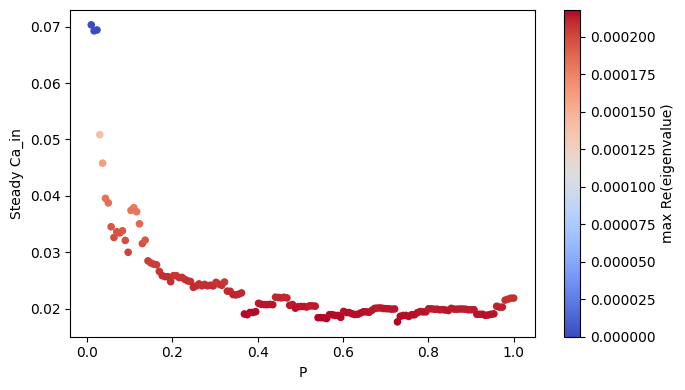

In [10]:
from scipy.optimize import root
import numpy as np

def steady_residuals(x, p, V=-60.0):
    C_0, C_in, C_SR, y = x

    Jin = J_in1(V, C_in, C_0, p)
    Jpm = J_PMCA_Hill(C_in, p)
    Jserca = J_SERCA_Hill(C_in, p)
    Jip3r = J_IP3R_Wang(C_SR, C_in, y, p)
    Jryr = J_RyR_Wang(C_SR, C_in, p)
    Jleak = J_leak(C_SR, C_in, p)

    f = np.zeros(4)
    f[0] = Jpm - Jin
    f[1] = p["delta"] * (Jin - Jpm) - Jserca + Jip3r + Jryr + Jleak
    f[2] = p["gamma"] * (Jserca - Jip3r - Jryr - Jleak)

    f1 = (p["k_-4"] * p["K_2"] * p["K_1"] + p["k_-2"] * p["K_4"] * p["P"]) * C_in / (
        p["K_4"] * p["K_2"] * (p["K_1"] + p["P"])
    )
    f2 = (p["k_-2"] * p["P"] + p["k_-4"] * p["K_3"]) / (p["K_3"] + p["P"])
    f[3] = f1 * (1.0 - y) - f2 * y

    return f

def solve_equilibrium(x0, p, V=-60.0):
    sol = root(lambda x: steady_residuals(x, p, V=V), x0, method="hybr")
    return sol

def continuation_over_P(P_values, x0, base_params, V=-60.0):
    branch = []
    x_guess = np.array(x0, dtype=float)

    for P in P_values:
        p = base_params.copy()
        p["P"] = float(P)

        sol = solve_equilibrium(x_guess, p, V=V)

        if not sol.success:
            branch.append({
                "P": P,
                "success": False,
                "x": np.full_like(x_guess, np.nan, dtype=float),
                "resnorm": np.nan
            })
            break

        x = sol.x
        branch.append({
            "P": P,
            "success": True,
            "x": x.copy(),
            "resnorm": np.linalg.norm(sol.fun)
        })

        x_guess = x

    return branch

params = get_default_params()
P_values = np.linspace(0.01, 1.0, 150)
x0 = [1002, 0.1, 25.0, 0.1]

branch = continuation_over_P(P_values, x0, params)

def fd_jacobian(fun, x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    n = len(x)
    J = np.zeros((n, n), dtype=float)
    f0 = fun(x)

    for i in range(n):
        dx = np.zeros(n)
        dx[i] = eps * max(1.0, abs(x[i]))
        fp = fun(x + dx)
        fm = fun(x - dx)
        J[:, i] = (fp - fm) / (2.0 * dx[i])

    return J

from numpy.linalg import eigvals

stability = []
for item in branch:
    if not item["success"]:
        stability.append(np.nan)
        continue

    P = item["P"]
    x = item["x"]
    p = params.copy()
    p["P"] = P

    J = fd_jacobian(lambda z: steady_residuals(z, p, V=-60.0), x)
    lam = eigvals(J)
    max_real = np.max(np.real(lam))
    stability.append(max_real)

import matplotlib.pyplot as plt

P_plot = []
Cin_plot = []
stab_plot = []

for item, s in zip(branch, stability):
    if item["success"]:
        P_plot.append(item["P"])
        Cin_plot.append(item["x"][1])
        stab_plot.append(s)

plt.figure(figsize=(7, 4))
sc = plt.scatter(P_plot, Cin_plot, c=stab_plot, cmap="coolwarm", s=20)
plt.xlabel("P")
plt.ylabel("Steady Ca_in")
plt.colorbar(sc, label="max Re(eigenvalue)")
plt.tight_layout()
plt.show()